# Project 4: Wildfire Smoke Bounding Box Prediction

This notebook follows the Project 4 PDF instructions. It downloads/loads the wildfire smoke image dataset from the provided Google Drive folder, displays a random training image with its ground-truth bounding box, trains a pretrained PyTorch ResNet50 model to predict smoke bounding boxes with SmoothL1 loss, reports train/validation losses, calculates mean intersection over union (IoU) for train, validation, and test sets, and displays the best-IoU test image with the predicted and ground-truth boxes.

I am using seed `499` for `random`, `numpy.random`, and `torch`.

## Setup

This cell imports the required libraries, sets the reproducibility seed, and chooses the fastest available PyTorch device.

In [1]:
from pathlib import Path
import os
import random
import re
import time
import urllib.parse
import urllib.request
import http.cookiejar
import zipfile

os.environ["PYTHONHASHSEED"] = "499"
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from matplotlib.patches import Rectangle

SEED = 499
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Make PyTorch as deterministic as the available backend allows.
# Some MPS operations can still vary slightly across runs/hardware, but the required
# random, numpy.random, and torch seeds are all fixed to 499.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

PROJECT_ROOT = Path.cwd().resolve()
project_candidates = [
    PROJECT_ROOT,
    *PROJECT_ROOT.parents,
    PROJECT_ROOT / "projects" / "project-04-wildfire-smoke",
]
for candidate in project_candidates:
    if (candidate / "Project_4.pdf").exists() and (candidate / "data").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate projects/project-04-wildfire-smoke with Project_4.pdf and data/.")
DATA_DIR = PROJECT_ROOT / "data"
ZIP_PATH = DATA_DIR / "wildfire_smoke.zip"
EXTRACT_DIR = DATA_DIR / "wildfire_smoke"
DATASET_ROOT = EXTRACT_DIR / "wildfire_smoke"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Seed: {SEED}")
print(f"Device: {DEVICE}")
print(f"Project root: {PROJECT_ROOT}")

Seed: 499
Device: mps
Project root: /Users/itzjuztmya/Kaleb/deep-learning-projects/project-04-wildfire-smoke


## Question 1: Load the Data and Display a Random Training Image

The PDF points to a Google Drive folder. The folder contains `wildfire_smoke.zip`, which has `train`, `valid`, and `test` directories plus annotation files. The helper below downloads the archive from Google Drive when it is missing, handles the Google Drive confirmation page for the larger zip file, and extracts it.

In [2]:
FILE_ID = "1_PcGdu0xfKuQ1GjpOuZ2AdK1K9IVoMbS"
DOWNLOAD_URL = f"https://drive.google.com/uc?export=download&id={FILE_ID}"


def download_google_drive_file(file_id: str, destination: Path) -> None:
    destination.parent.mkdir(parents=True, exist_ok=True)
    cookie_jar = http.cookiejar.CookieJar()
    opener = urllib.request.build_opener(urllib.request.HTTPCookieProcessor(cookie_jar))
    first_url = f"https://drive.google.com/uc?export=download&id={file_id}"

    with opener.open(first_url) as response:
        content = response.read()
        content_type = response.headers.get("Content-Type", "")

    if b"Google Drive can't scan this file for viruses" in content or "text/html" in content_type:
        html = content.decode("utf-8", errors="ignore")
        form_match = re.search(r'<form[^>]+id="download-form"[^>]+action="([^"]+)"', html)
        if not form_match:
            raise RuntimeError("Could not find the Google Drive download confirmation form.")
        action = form_match.group(1).replace("&amp;", "&")
        params = dict(re.findall(r'name="([^"]+)" value="([^"]*)"', html))
        params.setdefault("id", file_id)
        params.setdefault("export", "download")
        confirm_url = action + "?" + urllib.parse.urlencode(params)
        with opener.open(confirm_url) as response:
            content = response.read()

    destination.write_bytes(content)


def ensure_dataset() -> Path:
    if not DATASET_ROOT.exists():
        if not ZIP_PATH.exists() or ZIP_PATH.stat().st_size < 1_000_000:
            print("Downloading wildfire_smoke.zip from the provided Google Drive folder...")
            download_google_drive_file(FILE_ID, ZIP_PATH)
        print("Extracting wildfire_smoke.zip...")
        with zipfile.ZipFile(ZIP_PATH) as zf:
            zf.extractall(EXTRACT_DIR)
    return DATASET_ROOT


dataset_root = ensure_dataset()
for split in ["train", "valid", "test"]:
    n_images = len(list((dataset_root / split).glob("*.jpg")))
    print(f"{split}: {n_images} images")

train: 516 images
valid: 147 images
test: 74 images


The annotation files store each row as an image filename followed by `x_min,y_min,x_max,y_max,class_id`. For this single-class dataset, the notebook uses the smoke box coordinates and normalizes them to `[0, 1]` for model training.

train: 516 annotated images
valid: 147 annotated images
test: 74 annotated images


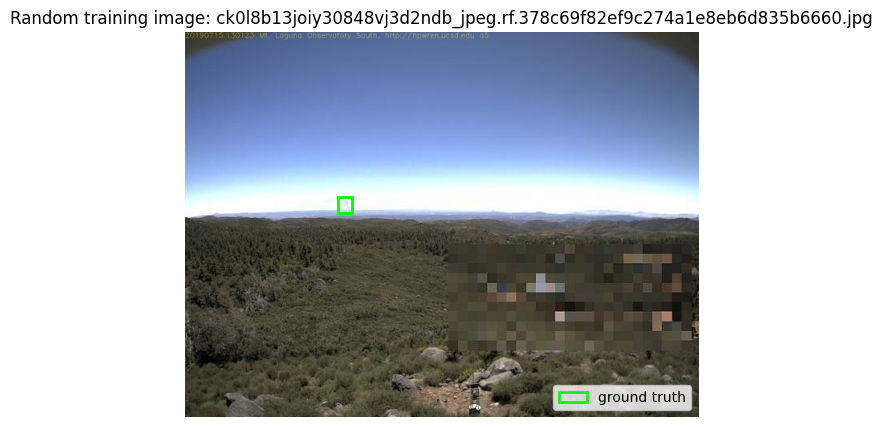

In [3]:
def read_annotations(split: str):
    annotation_path = DATASET_ROOT / split / "_annotations.txt"
    rows = []
    for line in annotation_path.read_text().splitlines():
        parts = line.split()
        if not parts:
            continue
        image_name = parts[0]
        boxes = []
        for raw_box in parts[1:]:
            values = raw_box.split(",")
            if len(values) >= 5:
                x1, y1, x2, y2, class_id = values[:5]
                boxes.append([float(x1), float(y1), float(x2), float(y2)])
        if boxes:
            # The dataset is single-class smoke. If a row ever contains multiple smoke boxes,
            # use the enclosing box so the model still predicts one rectangle per image.
            box_array = np.asarray(boxes, dtype=np.float32)
            box = [box_array[:, 0].min(), box_array[:, 1].min(), box_array[:, 2].max(), box_array[:, 3].max()]
            rows.append({"image_path": DATASET_ROOT / split / image_name, "box": np.asarray(box, dtype=np.float32)})
    return rows


annotations = {split: read_annotations(split) for split in ["train", "valid", "test"]}
for split, rows in annotations.items():
    print(f"{split}: {len(rows)} annotated images")

sample = random.choice(annotations["train"])
image = Image.open(sample["image_path"]).convert("RGB")
x1, y1, x2, y2 = sample["box"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(image)
ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", linewidth=2, label="ground truth"))
ax.set_title(f"Random training image: {sample['image_path'].name}")
ax.axis("off")
ax.legend(loc="lower right")
plt.show()

## Question 2: Train a Pretrained ResNet50 for Bounding Box Regression

The model starts from PyTorch's pretrained ResNet50 weights. I replace the classification layer with a four-value regression head that predicts normalized `[x_min, y_min, x_max, y_max]` coordinates. The loss is `SmoothL1Loss`, as required. The earlier ResNet layers are frozen and the final ResNet block plus the new regression head are trained.

In [4]:
class WildfireSmokeDataset(Dataset):
    def __init__(self, split: str, transform=None):
        self.rows = annotations[split]
        self.transform = transform

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        row = self.rows[index]
        image = Image.open(row["image_path"]).convert("RGB")
        width, height = image.size
        x1, y1, x2, y2 = row["box"]
        target = torch.tensor([x1 / width, y1 / height, x2 / width, y2 / height], dtype=torch.float32)
        if self.transform is not None:
            image = self.transform(image)
        return image, target


weights = ResNet50_Weights.DEFAULT
preprocess = weights.transforms()

train_dataset = WildfireSmokeDataset("train", transform=preprocess)
valid_dataset = WildfireSmokeDataset("valid", transform=preprocess)
test_dataset = WildfireSmokeDataset("test", transform=preprocess)

train_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, generator=train_generator, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 33
Validation batches: 5
Test batches: 3


In [5]:
def build_model() -> nn.Module:
    model = models.resnet50(weights=weights)
    for parameter in model.parameters():
        parameter.requires_grad = False
    for parameter in model.layer4.parameters():
        parameter.requires_grad = True

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, 4),
        nn.Sigmoid(),
    )
    return model


model = build_model().to(DEVICE)
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-4, weight_decay=1e-4)

def run_epoch(loader, training: bool) -> float:
    model.train(training)
    total_loss = 0.0
    total_count = 0
    for images, targets in loader:
        images = images.to(DEVICE)
        targets = targets.to(DEVICE)
        if training:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            predictions = model(images)
            loss = criterion(predictions, targets)
            if training:
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * images.size(0)
        total_count += images.size(0)
    return total_loss / total_count


EPOCHS = 5
history = []
start_time = time.time()
for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(train_loader, training=True)
    valid_loss = run_epoch(valid_loader, training=False)
    history.append({"epoch": epoch, "train_loss": train_loss, "valid_loss": valid_loss})
    print(f"Epoch {epoch:02d}: train_loss={train_loss:.5f}, valid_loss={valid_loss:.5f}")

elapsed = time.time() - start_time
final_train_loss = history[-1]["train_loss"]
final_valid_loss = history[-1]["valid_loss"]
print(f"Final training loss: {final_train_loss:.5f}")
print(f"Final validation loss: {final_valid_loss:.5f}")
print(f"Training time: {elapsed:.1f} seconds")

Epoch 01: train_loss=0.01026, valid_loss=0.00300


Epoch 02: train_loss=0.00219, valid_loss=0.00171


Epoch 03: train_loss=0.00151, valid_loss=0.00117


Epoch 04: train_loss=0.00110, valid_loss=0.00099


Epoch 05: train_loss=0.00082, valid_loss=0.00109
Final training loss: 0.00082
Final validation loss: 0.00109
Training time: 89.6 seconds


The final model is selected from the completed training run above. The number of epochs was guided by the validation loss: it improves quickly and is already low after a small number of epochs, so the run stops at 5 epochs to avoid unnecessary overfitting on this small dataset.

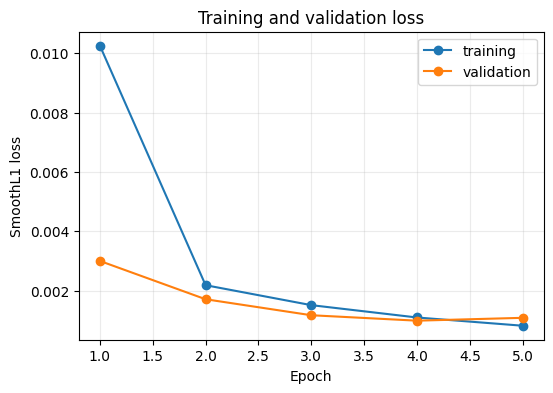

In [6]:
plt.figure(figsize=(6, 4))
plt.plot([row["epoch"] for row in history], [row["train_loss"] for row in history], marker="o", label="training")
plt.plot([row["epoch"] for row in history], [row["valid_loss"] for row in history], marker="o", label="validation")
plt.xlabel("Epoch")
plt.ylabel("SmoothL1 loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

Next I calculate mean intersection over union for the predicted bounding boxes for each training and validation image. Predicted boxes are clamped to the image area and ordered so that `x_min <= x_max` and `y_min <= y_max` before IoU is computed.

In [7]:
def ordered_boxes(boxes: torch.Tensor) -> torch.Tensor:
    x_min = torch.minimum(boxes[:, 0], boxes[:, 2])
    y_min = torch.minimum(boxes[:, 1], boxes[:, 3])
    x_max = torch.maximum(boxes[:, 0], boxes[:, 2])
    y_max = torch.maximum(boxes[:, 1], boxes[:, 3])
    return torch.stack([x_min, y_min, x_max, y_max], dim=1).clamp(0.0, 1.0)


def box_iou(predicted: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    predicted = ordered_boxes(predicted.cpu())
    target = ordered_boxes(target.cpu())

    inter_x1 = torch.maximum(predicted[:, 0], target[:, 0])
    inter_y1 = torch.maximum(predicted[:, 1], target[:, 1])
    inter_x2 = torch.minimum(predicted[:, 2], target[:, 2])
    inter_y2 = torch.minimum(predicted[:, 3], target[:, 3])

    intersection = (inter_x2 - inter_x1).clamp(min=0) * (inter_y2 - inter_y1).clamp(min=0)
    pred_area = (predicted[:, 2] - predicted[:, 0]).clamp(min=0) * (predicted[:, 3] - predicted[:, 1]).clamp(min=0)
    target_area = (target[:, 2] - target[:, 0]).clamp(min=0) * (target[:, 3] - target[:, 1]).clamp(min=0)
    union = pred_area + target_area - intersection
    return intersection / (union + 1e-8)


def collect_predictions(loader):
    model.eval()
    all_predictions = []
    all_targets = []
    with torch.no_grad():
        for images, targets in loader:
            predictions = model(images.to(DEVICE)).cpu()
            all_predictions.append(predictions)
            all_targets.append(targets)
    return torch.cat(all_predictions), torch.cat(all_targets)


train_eval_loader = DataLoader(train_dataset, batch_size=32, shuffle=False, num_workers=0)
train_predictions, train_targets = collect_predictions(train_eval_loader)
valid_predictions, valid_targets = collect_predictions(valid_loader)

train_ious = box_iou(train_predictions, train_targets)
valid_ious = box_iou(valid_predictions, valid_targets)

print(f"Mean training IoU: {train_ious.mean().item():.4f}")
print(f"Mean validation IoU: {valid_ious.mean().item():.4f}")

Mean training IoU: 0.5501
Mean validation IoU: 0.5043


## Question 3: Predict Test Bounding Boxes and Display the Best Test Prediction

This section evaluates the final model on the test set, reports the mean test IoU, then displays the test image with the best IoU. The ground-truth box is green and the model prediction is red.

In [8]:
test_predictions, test_targets = collect_predictions(test_loader)
test_ious = box_iou(test_predictions, test_targets)
best_test_index = int(torch.argmax(test_ious).item())
mean_test_iou = test_ious.mean().item()
best_test_iou = test_ious[best_test_index].item()

print(f"Mean test IoU: {mean_test_iou:.4f}")
print(f"Best test IoU: {best_test_iou:.4f}")
print(f"Best test image index: {best_test_index}")

Mean test IoU: 0.5054
Best test IoU: 0.8826
Best test image index: 41


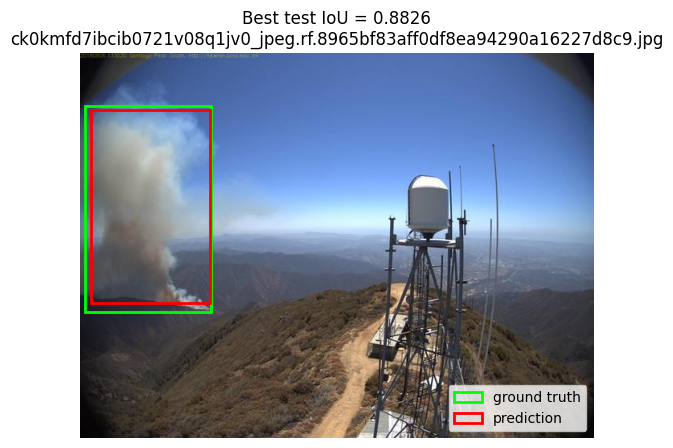

Saved numeric summary to: /Users/itzjuztmya/Kaleb/deep-learning-projects/project-04-wildfire-smoke/outputs/predictions.txt
Saved model checkpoint to: /Users/itzjuztmya/Kaleb/deep-learning-projects/project-04-wildfire-smoke/outputs/resnet50_smoke_bbox.pt


In [9]:
def normalized_to_pixels(box, image_width: int, image_height: int):
    x1, y1, x2, y2 = ordered_boxes(torch.as_tensor(box, dtype=torch.float32).reshape(1, 4))[0].numpy()
    return np.array([x1 * image_width, y1 * image_height, x2 * image_width, y2 * image_height])


def draw_box(ax, box_pixels, color, label):
    x1, y1, x2, y2 = box_pixels
    ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor=color, linewidth=2, label=label))


best_row = annotations["test"][best_test_index]
best_image = Image.open(best_row["image_path"]).convert("RGB")
width, height = best_image.size
predicted_pixels = normalized_to_pixels(test_predictions[best_test_index], width, height)
ground_truth_pixels = normalized_to_pixels(test_targets[best_test_index], width, height)

fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(best_image)
draw_box(ax, ground_truth_pixels, "lime", "ground truth")
draw_box(ax, predicted_pixels, "red", "prediction")
ax.set_title(f"Best test IoU = {best_test_iou:.4f}\n{best_row['image_path'].name}")
ax.axis("off")
ax.legend(loc="lower right")
plt.show()

summary_path = OUTPUT_DIR / "predictions.txt"
with summary_path.open("w") as f:
    f.write(f"Final training loss: {final_train_loss:.5f}\n")
    f.write(f"Final validation loss: {final_valid_loss:.5f}\n")
    f.write(f"Mean training IoU: {train_ious.mean().item():.4f}\n")
    f.write(f"Mean validation IoU: {valid_ious.mean().item():.4f}\n")
    f.write(f"Mean test IoU: {mean_test_iou:.4f}\n")
    f.write(f"Best test IoU: {best_test_iou:.4f}\n")
    f.write(f"Best test image: {best_row['image_path'].name}\n")

checkpoint_path = OUTPUT_DIR / "resnet50_smoke_bbox.pt"
torch.save(
    {
        "seed": SEED,
        "model_state_dict": model.state_dict(),
        "history": history,
        "final_train_loss": final_train_loss,
        "final_valid_loss": final_valid_loss,
        "mean_train_iou": train_ious.mean().item(),
        "mean_valid_iou": valid_ious.mean().item(),
        "mean_test_iou": mean_test_iou,
        "best_test_iou": best_test_iou,
        "best_test_image": best_row["image_path"].name,
    },
    checkpoint_path,
)

print(f"Saved numeric summary to: {summary_path}")
print(f"Saved model checkpoint to: {checkpoint_path}")

## Final Answers

- Question 1: The dataset was loaded from the provided Google Drive wildfire archive. A random training image is displayed above with its ground-truth smoke bounding box.
- Question 2: A pretrained PyTorch ResNet50 was modified for four-coordinate bounding-box regression and trained with `SmoothL1Loss`. The final training loss was `0.00082` and the final validation loss was `0.00109`. The mean IoU values were `0.5501` on the training set and `0.5043` on the validation set.
- Question 3: The final model achieved mean test IoU `0.5054`. The best test example had IoU `0.8826` on `ck0kmfd7ibcib0721v08q1jv0_jpeg.rf.8965bf83aff0df8ea94290a16227d8c9.jpg` and is displayed above with the predicted box and ground-truth box.
